In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
df=pd.read_csv("Titanic-Dataset.csv",index_col="PassengerId")

In [46]:
numerical_columns=df.select_dtypes(include=['number']).columns
categorical_columns=df.select_dtypes(include=['category']).columns
mixed_columns=df.select_dtypes(include=["object"]).columns


In [47]:
assert len(numerical_columns)+len(categorical_columns)+len(mixed_columns)==len(df.columns)

In [48]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [50]:
numerical_columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

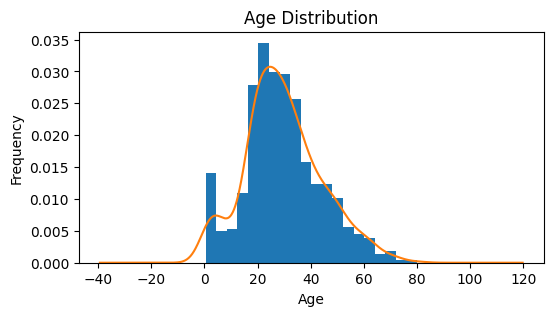

In [51]:
plt.figure(figsize=(6,3))
df["Age"].plot(kind="hist",bins=20,density=True)
df["Age"].plot(kind="kde")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

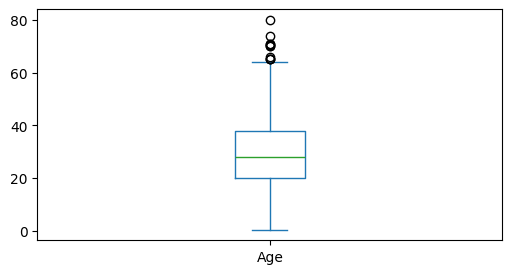

In [52]:
plt.figure(figsize=(6,3))
df["Age"].plot(kind="box")
plt.show()

In [53]:
df["Age"].skew()

np.float64(0.38910778230082704)

In [54]:
df["Age"].isnull().sum()/len(df["Age"])*100

np.float64(19.865319865319865)

There is no unusual age in data all ages are legitimate. and the data regardign the age of some people is not known. 

In [55]:
df["Fare"].isnull().sum()

np.int64(0)

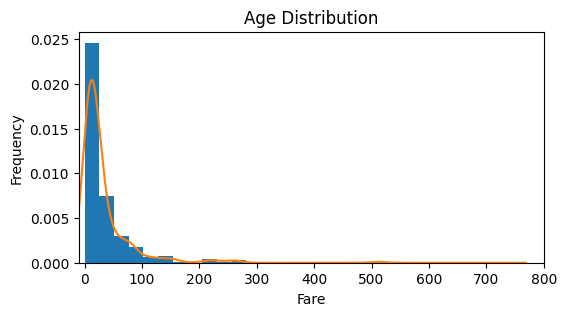

In [56]:
plt.figure(figsize=(6,3))
df["Fare"].plot(kind="hist",bins=20,density=True)
df["Fare"].plot(kind="kde")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.xlim((-10,800))
plt.show()

In [57]:
df["Fare"].skew()

np.float64(4.787316519674893)

There are few people who have not paid any price for ticket while some paid above 500 dollar.Lets see for this kind peopel.


<Axes: >

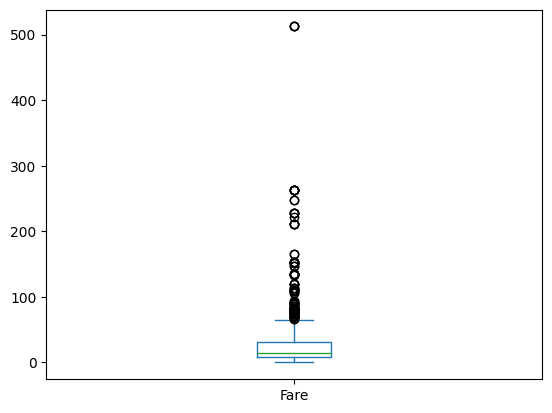

In [58]:
df["Fare"].plot(kind="box")

In [59]:
df[df["Fare"]==0].head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S


In [60]:
df[df["Fare"]>250].head(20)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


- In data fare there is noise same ticke with highg fare are allocated to many pessenger. This leads us to took the add new feature fare per head
- Data is hgihly positive skewed


## Univariate Analysis in Categorical Feature

<Axes: ylabel='count'>

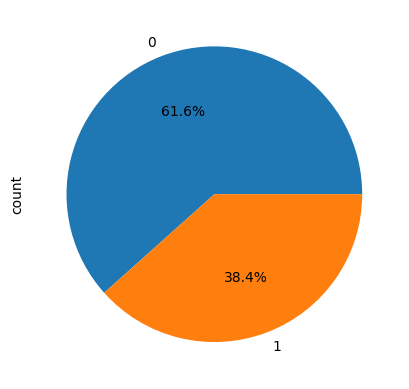

In [61]:
df["Survived"].value_counts().plot(kind="pie",autopct='%0.1f%%')

In [62]:
df["Survived"].isnull().sum()

np.int64(0)

<Axes: ylabel='count'>

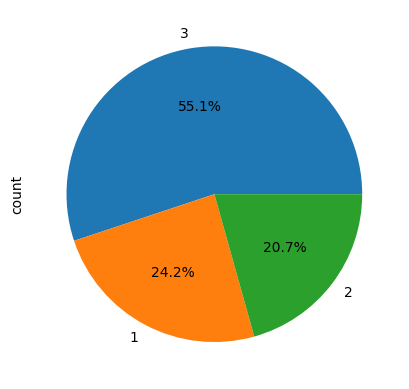

In [63]:
df["Pclass"].value_counts().plot(kind="pie",autopct="%0.1f%%")

<Axes: ylabel='count'>

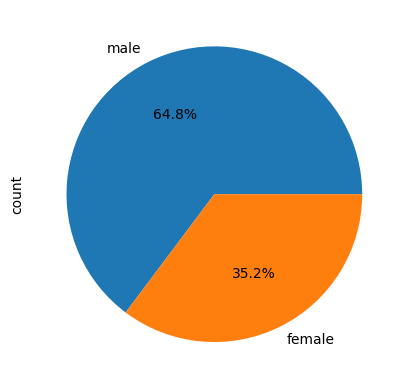

In [64]:
df["Sex"].value_counts().plot(kind="pie",autopct="%0.1f%%")

<Axes: ylabel='count'>

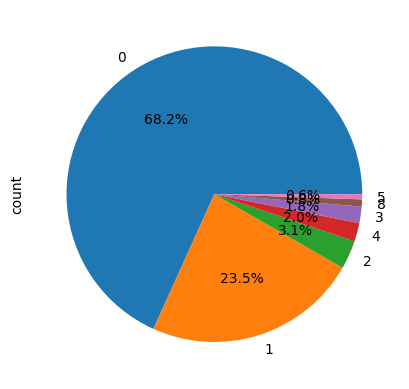

In [65]:
df["SibSp"].value_counts().plot(kind="pie",autopct="%0.1f%%")

<Axes: ylabel='count'>

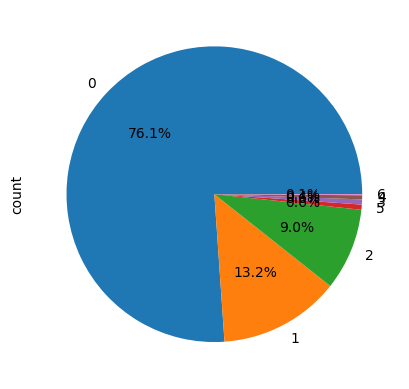

In [66]:
df["Parch"].value_counts().plot(kind="pie",autopct="%0.1f%%")

In [67]:
df[df["Parch"]>0]["Survived"].value_counts()

Survived
1    109
0    104
Name: count, dtype: int64

<Axes: ylabel='count'>

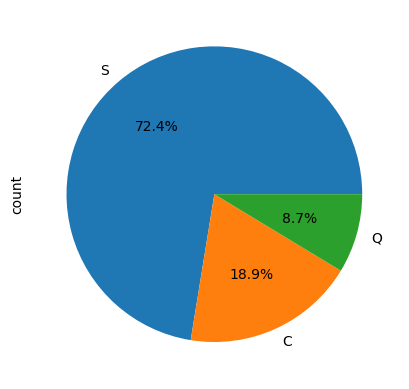

In [68]:
df["Embarked"].value_counts().plot(kind="pie",autopct="%0.1f%%")

## Bivariate Analysis


In [69]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
pd.crosstab(df["Pclass"],df["Survived"],normalize="index")

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [71]:
df[(df["Pclass"]==1) &(df["Sex"]=="female")].head(20)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S
152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,C2,S


<Axes: xlabel='Survived', ylabel='Pclass'>

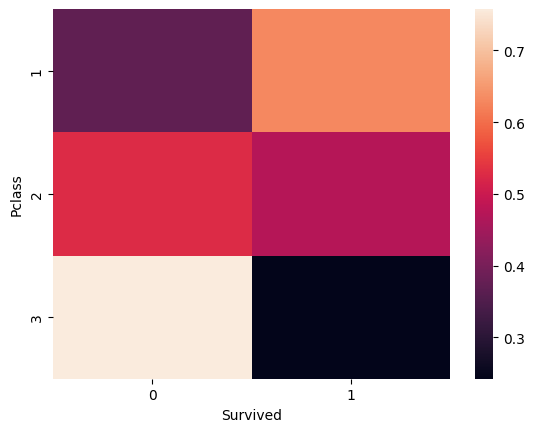

In [72]:

sns.heatmap(pd.crosstab(df["Pclass"],df["Survived"],normalize="index"))

Pclass 1 has high probability of survival.

<Axes: xlabel='Sex', ylabel='Survived'>

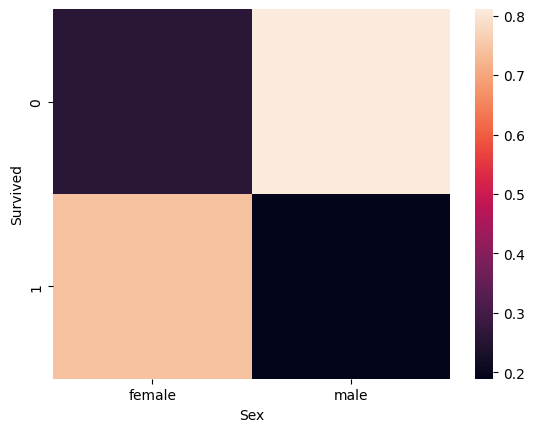

In [73]:
sns.heatmap(pd.crosstab(df["Survived"],df["Sex"],normalize="columns"))

In [74]:
pd.crosstab(df["Survived"],df["Sex"],normalize="columns")

Sex,female,male
Survived,,
0,0.257962,0.811092
1,0.742038,0.188908


- Being a female have high probabilty of survival

In [75]:
pd.crosstab(df["Embarked"],df["Survived"],normalize="index")

Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


In [76]:
pd.crosstab(df["Embarked"],df["Pclass"],normalize="index")

Pclass,1,2,3
Embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


In [77]:
df["Cabin"].isnull().sum()/len(df["Cabin"])

np.float64(0.7710437710437711)

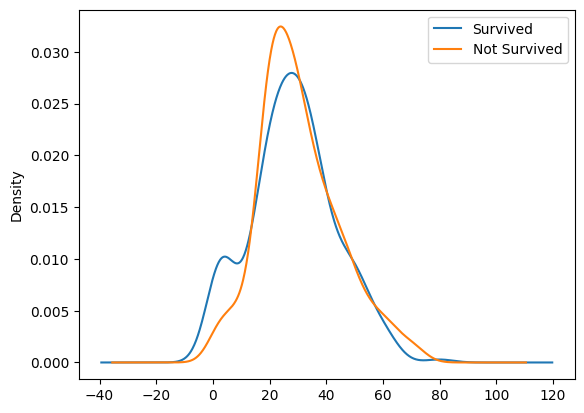

In [78]:
df[df["Survived"]==1]["Age"].plot(kind="kde",label="Survived")
df[df["Survived"]==0]["Age"].plot(kind="kde",label="Not Survived")
plt.legend()

# Feature Engineering in Sibling Spouse

In [79]:
df["individual_feature"]=df["Fare"]/(df["SibSp"]+df["Parch"]+1)

In [80]:
df[(df["Age"]<15) & (df["SibSp"]>2)]["Survived"].value_counts()

Survived
0    25
1     2
Name: count, dtype: int64

In [81]:
df["Cabin"].fillna("M",inplace=True)

/var/folders/pv/vtygm6gj545df0kvtb0zs3080000gn/T/ipykernel_27408/3691106463.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Cabin"].fillna("M",inplace=True)


In [82]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_feature
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,3.62500
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,7.92500
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,8.05000


In [83]:
df["Deck"]=df["Cabin"].str.get(0)

In [85]:
pd.crosstab(df["Survived"],df["Deck"],normalize="columns")

Deck,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0,0.533333,0.255319,0.40678,0.242424,0.25,0.384615,0.5,0.700146,1.0
1,0.466667,0.744681,0.59322,0.757576,0.75,0.615385,0.5,0.299854,0.0


In [91]:
df["FamilySize"]=df["Parch"]+df["SibSp"]+1

In [94]:
bin_size=[-1,1,4,6,15]
size_labels = ['single', 'small', 'medium', 'large']
df['Group_Size'] = pd.cut(df['FamilySize'], bins=bin_size, labels=size_labels)

In [95]:
pd.crosstab(df["Survived"],df["Group_Size"],normalize="columns")

Group_Size,single,small,medium,large
Survived,,,,
0,0.696462,0.421233,0.837838,0.84
1,0.303538,0.578767,0.162162,0.16


In [96]:
new_df=df.copy()

In [97]:
new_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_feature,Deck,FamilySize,Group_Size
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,3.62500,M,2,small
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,C,2,small
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,7.92500,M,1,single
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,C,2,small
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,8.05000,M,1,single


In [98]:
new_df.drop(columns=["Name","Ticket","Fare","Cabin"],inplace=True)

In [99]:
new_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,individual_feature,Deck,FamilySize,Group_Size
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,S,3.62500,M,2,small
2,1,1,female,38.0,1,0,C,35.64165,C,2,small
3,1,3,female,26.0,0,0,S,7.92500,M,1,single
4,1,1,female,35.0,1,0,S,26.55000,C,2,small
5,0,3,male,35.0,0,0,S,8.05000,M,1,single
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,S,13.00000,M,1,single
888,1,1,female,19.0,0,0,S,30.00000,B,1,single
889,0,3,female,NaN,1,2,S,5.86250,M,4,small


In [100]:
df[df["Embarked"].isna()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_feature,Deck,FamilySize,Group_Size
PassengerId,,,,,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,80.0,B,1,single
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,80.0,B,1,single


In [101]:
new_df.isnull().sum()

Survived                0
Pclass                  0
Sex                     0
Age                   177
SibSp                   0
Parch                   0
Embarked                2
individual_feature      0
Deck                    0
FamilySize              0
Group_Size              0
dtype: int64

In [ ]:
fig ,axes = plt.subplots(nrows=1,ncols=2,figsize=(20,10))
df["Survived"].plot(kind="hist",ax=axes[0],color="yellow")
new_df["Survived"].plot(kind="hist",ax=axes[0],color="black")
axes[0].set_title("Distirbution of Survival before and after removing Embarked Data")



df["Age"].plot(kind="kde",ax=axes[1],color="blue")
new_df["Age"].plot(kind="kde",ax=axes[1],color="black")
axes[1].set_title("Distribution of Age before and after removing Embarked Data")



In [ ]:
df.describe()


In [ ]:
new_df.describe()

- Since removing the two rows the distrubiton of data approxmately remains same. So remvong only two rows has zero impact.


In [ ]:
new_df['Embarked']=

KeyError: ''